In [21]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import preprocess_fun as fun

from geomstats.geometry.pre_shape import PreShapeSpace
from geomstats.learning.frechet_mean import FrechetMean
from geomstats.learning.incremental_frechet_mean import IncrementalFrechetMean

In [22]:
hand_data = scipy.io.loadmat('Hand_Shapes.mat')
hands = np.stack([hand_data['XX'], hand_data['YY']], axis=-1)
hand_uni = fun.obj_align(fun.unify(hands))

In [23]:
k_landmark = 100
m_ambient = 2
preshape = PreShapeSpace(k_landmark, m_ambient)
preshape.equip_with_group_action('rotations')
preshape.equip_with_quotient()

hand_preshape = preshape.projection(hand_uni)

mean_frechet = FrechetMean(preshape)
mean_incremental = IncrementalFrechetMean(preshape)

hand_mean_frechet = mean_frechet.fit(hand_preshape).estimate_
hand_mean_incremental = mean_incremental.fit(hand_preshape).estimate_
hand_mean_recursive = fun.Rec_Frechet_mean_geom(hand_uni)



(-0.11929193829667971,
 0.16050667785473807,
 -0.1000277178272124,
 0.1414510881411236)

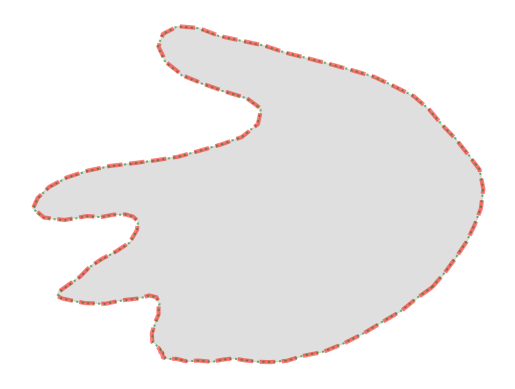

In [24]:
plt.fill(hand_mean_frechet[:,0], hand_mean_frechet[:,1], color = 'silver', alpha = 0.5, label = 'eFM')
plt.plot(hand_mean_incremental[:,0], hand_mean_incremental[:,1], linestyle='--', color = 'r', alpha = 0.5, linewidth = 3, label = 'iFME')
plt.plot(hand_mean_recursive[:,0], hand_mean_recursive[:,1], linestyle=':', color = 'g', alpha = 0.5, label = 'RFME')
#plt.legend()
plt.axis('off')

In [25]:
eFM_TE = 0
iFME_TE = 0
RFME_TE = 0
for i in range(hand_preshape.shape[0]):
    eFM_TE += preshape.quotient.metric.dist(hand_mean_frechet, hand_preshape[i])
    iFME_TE += preshape.quotient.metric.dist(hand_mean_incremental, hand_preshape[i])
    RFME_TE += preshape.quotient.metric.dist(hand_mean_recursive, hand_preshape[i])

In [26]:
print('eFM:', eFM_TE, '\niFME:', iFME_TE, '\nRFME:', RFME_TE)

eFM: 1.8047120640247691 
iFME: 1.8054579158855646 
RFME: 1.8053597492346323


In [27]:
print('eFM:', fun.SSE(hand_mean_frechet, hand_preshape), '\niFME:', fun.SSE(hand_mean_incremental, hand_preshape), '\nRFME:', fun.SSE(hand_mean_recursive, hand_preshape))

eFM: 0.41141438524972523 
iFME: 0.41137416672837085 
RFME: 0.41136923367939005
